## 7B dataset distribution

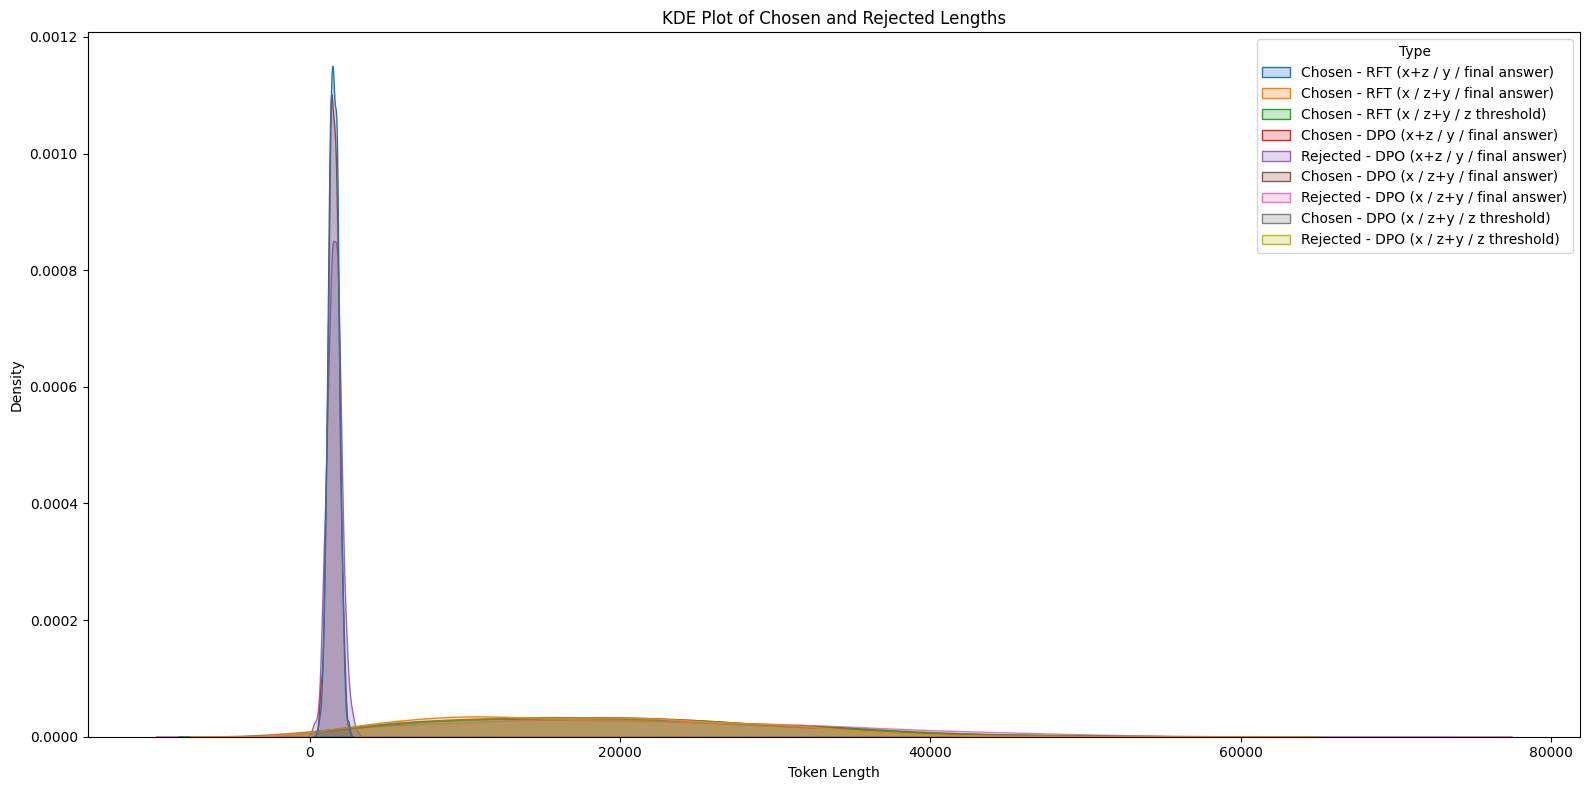

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Dataset stats
data = [
    # name, input_mean, input_std, chosen_mean, chosen_std, rejected_mean, rejected_std
    ("RFT (x+z / y / final answer)", 17705.46, 14605.60, 1518.21, 328.48, None, None),
    ("RFT (x / z+y / final answer)", 433.58, 166.29, 15796.51, 11553.42, None, None),
    ("RFT (x / z+y / z threshold)", 439.86, 180.12, 17097.89, 13327.89, None, None),
    ("DPO (x+z / y / final answer)", 17705.40, 14605.60, 1518.21, 328.48, 1571.88, 444.44),
    ("DPO (x / z+y / final answer)", 433.58, 166.29, 17291.06, 13263.17, 18177.33, 14882.57),
    ("DPO (x / z+y / z threshold)", 439.86, 180.12, 17097.89, 13327.89, 17213.60, 13552.87),
]

# Expand mean and std into distributions to simulate percentiles
def simulate_values(mean, std, label, n=1000):
    if mean is None or std is None:
        return []
    import numpy as np
    values = np.random.normal(loc=mean, scale=std, size=n)
    values = values[values > 0]  # remove negative lengths
    return pd.DataFrame({'Length': values, 'Type': label})

dfs = []
for d in data:
    name, _, _, c_mean, c_std, r_mean, r_std = d
    dfs.append(simulate_values(c_mean, c_std, f"Chosen - {name}"))
    if r_mean is not None:
        dfs.append(simulate_values(r_mean, r_std, f"Rejected - {name}"))

df = pd.concat(dfs, ignore_index=True)

# Plot
plt.figure(figsize=(16, 8))
sns.kdeplot(data=df, x="Length", hue="Type", common_norm=False, fill=True)
plt.title("KDE Plot of Chosen and Rejected Lengths")
plt.xlabel("Token Length")
plt.ylabel("Density")
plt.tight_layout()
plt.show()



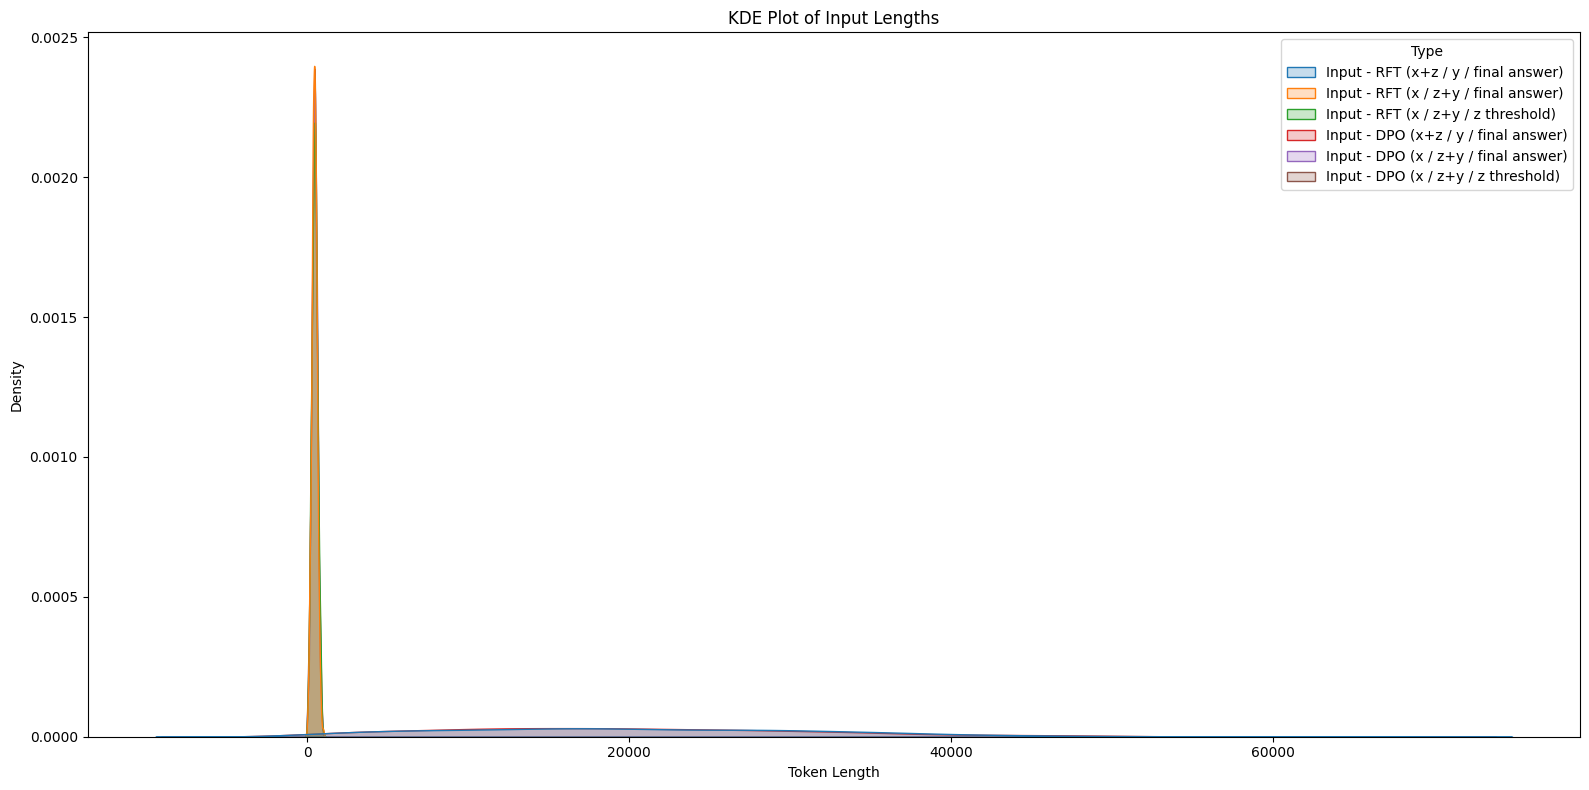

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Dataset stats
data = [
    # name, input_mean, input_std, chosen_mean, chosen_std, rejected_mean, rejected_std
    ("RFT (x+z / y / final answer)", 17705.46, 14605.60, 1518.21, 328.48, None, None),
    ("RFT (x / z+y / final answer)", 433.58, 166.29, 15796.51, 11553.42, None, None),
    ("RFT (x / z+y / z threshold)", 439.86, 180.12, 17097.89, 13327.89, None, None),
    ("DPO (x+z / y / final answer)", 17705.40, 14605.60, 1518.21, 328.48, 1571.88, 444.44),
    ("DPO (x / z+y / final answer)", 433.58, 166.29, 17291.06, 13263.17, 18177.33, 14882.57),
    ("DPO (x / z+y / z threshold)", 439.86, 180.12, 17097.89, 13327.89, 17213.60, 13552.87),
]

# Expand mean and std into distributions to simulate percentiles
def simulate_values(mean, std, label, n=1000):
    if mean is None or std is None:
        return []
    import numpy as np
    values = np.random.normal(loc=mean, scale=std, size=n)
    values = values[values > 0]  # remove negative lengths
    return pd.DataFrame({'Length': values, 'Type': label})

dfs = []
for d in data:
    name, i_mean, i_std, _, _, _, _ = d
    dfs.append(simulate_values(i_mean, i_std, f"Input - {name}"))

df = pd.concat(dfs, ignore_index=True)

# Plot
plt.figure(figsize=(16, 8))
sns.kdeplot(data=df, x="Length", hue="Type", common_norm=False, fill=True)
plt.title("KDE Plot of Input Lengths")
plt.xlabel("Token Length")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

